# Preamble

In [97]:
import pandas as pd
import numpy as np

import math

from scipy import stats
from scipy.stats import normaltest , mannwhitneyu ,levene,chi2_contingency ,  pearsonr, spearmanr
from statsmodels.stats.oneway import anova_oneway

import pingouin as pg

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv('Raw_Data/customer.csv')
order = pd.read_csv('Raw_Data/order.csv')
order_detail = pd.read_csv('Raw_Data/order_detail.csv')
product = pd.read_csv('Raw_Data/product.csv')
returned = pd.read_csv('Raw_Data/returned.csv')
shipping = pd.read_csv('Raw_Data/shipping.csv')

# Preprocessing

In [3]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Customer ID    1589 non-null   str  
 1   Customer Name  1589 non-null   str  
 2   Segment        1589 non-null   str  
dtypes: str(3)
memory usage: 82.9 KB


In [4]:
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Order ID        25033 non-null  str  
 1   Customer ID     25033 non-null  str  
 2   Order Priority  25033 non-null  str  
 3   Order Date      25033 non-null  str  
 4   Market          25033 non-null  str  
dtypes: str(5)
memory usage: 2.1 MB


In [5]:
order_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         49670 non-null  int64  
 1   Order ID       49670 non-null  str    
 2   Product ID     49670 non-null  str    
 3   Sales          49670 non-null  float64
 4   Quantity       49670 non-null  int64  
 5   Discount       49670 non-null  float64
 6   Profit         49670 non-null  float64
 7   Shipping Cost  49670 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 4.4 MB


In [6]:
product.info()

<class 'pandas.DataFrame'>
RangeIndex: 10246 entries, 0 to 10245
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Product ID    10246 non-null  str  
 1   Product Name  10246 non-null  str  
 2   Category      10246 non-null  str  
 3   Sub-Category  10246 non-null  str  
dtypes: str(4)
memory usage: 983.2 KB


In [7]:
returned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Order ID  1172 non-null   str  
dtypes: str(1)
memory usage: 25.3 KB


In [8]:
shipping.info()

<class 'pandas.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Shipping ID  25033 non-null  int64
 1   Order ID     25033 non-null  str  
 2   Ship Date    25033 non-null  str  
 3   Ship Mode    25033 non-null  str  
 4   City         25033 non-null  str  
 5   State        25033 non-null  str  
 6   Country      25033 non-null  str  
 7   Region       25033 non-null  str  
dtypes: int64(1), str(7)
memory usage: 3.4 MB


In [9]:
customer.head()

,Customer ID,Customer Name,Segment
0,AA-10315,Alex Avila,Consumer
1,AA-10375,Allen Armold,Consumer
2,AA-10480,Andrew Allen,Consumer
3,AA-10645,Anna Andreadi,Consumer
4,AA-315,Alex Avila,Consumer


In [10]:
order.head()

,Order ID,Customer ID,Order Priority,Order Date,Market
0,AE-2011-9160,PO-8865,Medium,2011-10-03 00:00:00,EMEA
1,AE-2013-1130,EB-4110,High,2013-10-14 00:00:00,EMEA
2,AE-2013-1530,MY-7380,High,2013-12-31 00:00:00,EMEA
3,AE-2014-2840,PG-8820,Critical,2014-11-05 00:00:00,EMEA
4,AE-2014-3830,GH-4665,Medium,2014-12-13 00:00:00,EMEA


In [11]:
order_detail.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787


In [12]:
product.head()

,Product ID,Product Name,Category,Sub-Category
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings


In [13]:
returned.head()

,Order ID
0,CA-2011-100762
1,CA-2011-100867
2,CA-2011-102652
3,CA-2011-103373
4,CA-2011-103744


In [14]:
shipping.head()

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
0,21043,CA-2012-124891,2012-07-31 00:00:00,Same Day,New York City,New York,United States,East
1,21044,IN-2013-77878,2013-02-07 00:00:00,Second Class,Wollongong,New South Wales,Australia,Oceania
2,21045,IN-2013-71249,2013-10-18 00:00:00,First Class,Brisbane,Queensland,Australia,Oceania
3,21046,ES-2013-1579342,2013-01-30 00:00:00,First Class,Berlin,Berlin,Germany,Central
4,21047,SG-2013-4320,2013-11-06 00:00:00,Same Day,Dakar,Dakar,Senegal,Africa


In [15]:
customer.describe()

,Customer ID,Customer Name,Segment
count,1589,1589,1589
unique,1589,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,2,817


In [16]:
order.describe()

,Order ID,Customer ID,Order Priority,Order Date,Market
count,25033,25033,25033,25033,25033
unique,25033,1589,4,1428,7
top,AE-2011-9160,PO-18850,Medium,2014-11-25 00:00:00,APAC
freq,1,41,14344,59,5437


In [17]:
order_detail.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,25763.380974,243.840355,3.470787,0.143070,28.392264,26.041125
std,14838.084164,485.963091,2.274854,0.212046,172.399520,56.870281
min,1.000000,0.444000,1.000000,0.000000,-6599.980000,0.002000
25%,12749.250000,30.384000,2.000000,0.000000,0.000000,2.580000
50%,26073.500000,83.970000,3.000000,0.000000,9.154000,7.660000
75%,38522.750000,247.830000,5.000000,0.200000,36.266400,23.969000
max,51290.000000,22638.500000,14.000000,0.850000,8399.980000,933.570000


In [18]:
product.describe()

,Product ID,Product Name,Category,Sub-Category
count,10246,10246,10246,10246
unique,10246,3662,3,17
top,FUR-ADV-10000002,Staples,Office Supplies,Paper
freq,1,45,5674,779


In [19]:
returned.describe()

,Order ID
count,1172
unique,1172
top,CA-2011-100762
freq,1


In [20]:
shipping.describe(include='all')

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
count,25033.00000,25033,25033,25033,25033,25033,25033,25033
unique,NaN,25033,1464,4,3590,1089,147,13
top,NaN,CA-2012-124891,2014-11-17 00:00:00,Standard Class,New York City,California,United States,Central
freq,NaN,1,54,15011,448,1016,4990,5238
mean,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7226.54898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,21043.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27301.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,39817.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
customer['Customer Name'].duplicated().sum()

np.int64(794)

In [22]:
canonical_lookup = customer.groupby('Customer Name')['Customer ID'].first().to_dict()

In [23]:
id_to_name = customer.set_index('Customer ID')['Customer Name'].to_dict()
id_to_canonical = {cid: canonical_lookup[name] for cid, name in id_to_name.items()}

In [24]:
order['Customer ID'] = order['Customer ID'].map(id_to_canonical).fillna(order['Customer ID'])

In [25]:
customer = customer.drop_duplicates(subset=['Customer Name'], keep='first')

In [26]:
customer.describe()

,Customer ID,Customer Name,Segment
count,795,795,795
unique,795,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,1,409


In [27]:
returned["Returned"] = 1

In [28]:
df = order_detail.merge(order, on="Order ID", how="left")
df = df.merge(product, on="Product ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(returned , on="Order ID" , how="left")

In [29]:
df

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Customer Name,Segment,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-10575,Medium,...,Sonia Cooley,Consumer,44634,2014-10-06 00:00:00,Standard Class,Mexico City,Distrito Federal,Mexico,North,NaN
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49665,51286,HU-2012-7730,OFF-AVE-10004570,11.07,1,0.0,3.42,1.980,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49666,51287,HU-2012-7730,TEC-LOG-10004419,61.44,2,0.0,18.42,13.020,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49667,51288,HU-2012-7730,OFF-BOS-10002705,80.52,4,0.0,20.88,8.780,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49668,51289,HU-2012-7730,OFF-ENE-10004132,130.44,4,0.0,33.84,18.970,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN


In [30]:
df['Row ID'].unique()

array([    1,     2,     3, ..., 51288, 51289, 51290], shape=(49670,))

In [31]:
df.drop(columns="Row ID" , inplace=True)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        49670 non-null  str    
 1   Product ID      49670 non-null  str    
 2   Sales           49670 non-null  float64
 3   Quantity        49670 non-null  int64  
 4   Discount        49670 non-null  float64
 5   Profit          49670 non-null  float64
 6   Shipping Cost   49670 non-null  float64
 7   Customer ID     49670 non-null  str    
 8   Order Priority  49670 non-null  str    
 9   Order Date      49670 non-null  str    
 10  Market          49670 non-null  str    
 11  Product Name    49670 non-null  str    
 12  Category        49670 non-null  str    
 13  Sub-Category    49670 non-null  str    
 14  Customer Name   49670 non-null  str    
 15  Segment         49670 non-null  str    
 16  Shipping ID     49670 non-null  int64  
 17  Ship Date       49670 non-null  str    
 1

In [33]:
df["Returned"] = df["Returned"].fillna(0)

In [34]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping ID,Returned
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840355,3.470787,0.143070,28.392264,26.041125,31632.081639,0.059996
std,485.963091,2.274854,0.212046,172.399520,56.870281,6964.662856,0.237482
min,0.444000,1.000000,0.000000,-6599.980000,0.002000,21043.000000,0.000000
25%,30.384000,2.000000,0.000000,0.000000,2.580000,25564.000000,0.000000
50%,83.970000,3.000000,0.000000,9.154000,7.660000,30862.000000,0.000000
75%,247.830000,5.000000,0.200000,36.266400,23.969000,37182.750000,0.000000
max,22638.500000,14.000000,0.850000,8399.980000,933.570000,46075.000000,1.000000


In [35]:
df = df.astype({
    "Quantity": "int8",
    "Shipping ID": "int32",
    "Sales": "float32",
    "Discount": "float32",
    "Profit": "float32",
    "Shipping Cost": "float32",
    "Returned": "int8",
})

In [36]:
category_dict = {
    "Order Priority": "category",
    "Market": "category",
    "Category": "category",
    "Sub-Category": "category",
    "Segment": "category",
    "Ship Mode": "category",
    "City": "category",
    "State": "category",
    "Country": "category",
    "Region": "category",
}

df = df.astype(category_dict)

In [37]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        49670 non-null  str           
 1   Product ID      49670 non-null  str           
 2   Sales           49670 non-null  float32       
 3   Quantity        49670 non-null  int8          
 4   Discount        49670 non-null  float32       
 5   Profit          49670 non-null  float32       
 6   Shipping Cost   49670 non-null  float32       
 7   Customer ID     49670 non-null  str           
 8   Order Priority  49670 non-null  category      
 9   Order Date      49670 non-null  datetime64[us]
 10  Market          49670 non-null  category      
 11  Product Name    49670 non-null  str           
 12  Category        49670 non-null  category      
 13  Sub-Category    49670 non-null  category      
 14  Customer Name   49670 non-null  str           
 15  Segment      

In [39]:
numeric_columns = ['Sales' , 'Quantity' , 'Discount' , 'Profit' , 'Shipping Cost']

In [40]:
categorical_columns = ["Order Priority" ,
"Market" , 
"Category" , 
"Sub-Category" ,
"Segment" , 
"Ship Mode" ,
"City" , 
"State" , 
"Country" , 
"Region" ,
"Returned", ]

## Duplicates

In [41]:
df.duplicated().sum()

np.int64(0)

## Nan

In [42]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [43]:
nan_percentage(df)

,Missing Count,Nan Percent
Order ID,0,0.0
Product ID,0,0.0
Sales,0,0.0
Quantity,0,0.0
Discount,0,0.0
Profit,0,0.0
Shipping Cost,0,0.0
Customer ID,0,0.0
Order Priority,0,0.0
Order Date,0,0.0


# EDA

## Normality

In [44]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:
    
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    results = []
    
    for col in columns:
        clean_data = df[col].dropna()
        n = len(clean_data)
        
        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue
        
        stat, p_value = normaltest(clean_data)
        
        result = "Normal" if p_value > alpha else "Not normal"
        
        results.append([col, n, p_value, result])
    
    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )
    
    return result_df

In [45]:
normality_checker(df)

,Column,Sample Size,p-value,Result
0,Sales,49670,0.0,Not normal
1,Quantity,49670,0.0,Not normal
2,Discount,49670,0.0,Not normal
3,Profit,49670,0.0,Not normal
4,Shipping Cost,49670,0.0,Not normal
5,Shipping ID,49670,0.0,Not normal
6,Returned,49670,0.0,Not normal


## Visualization

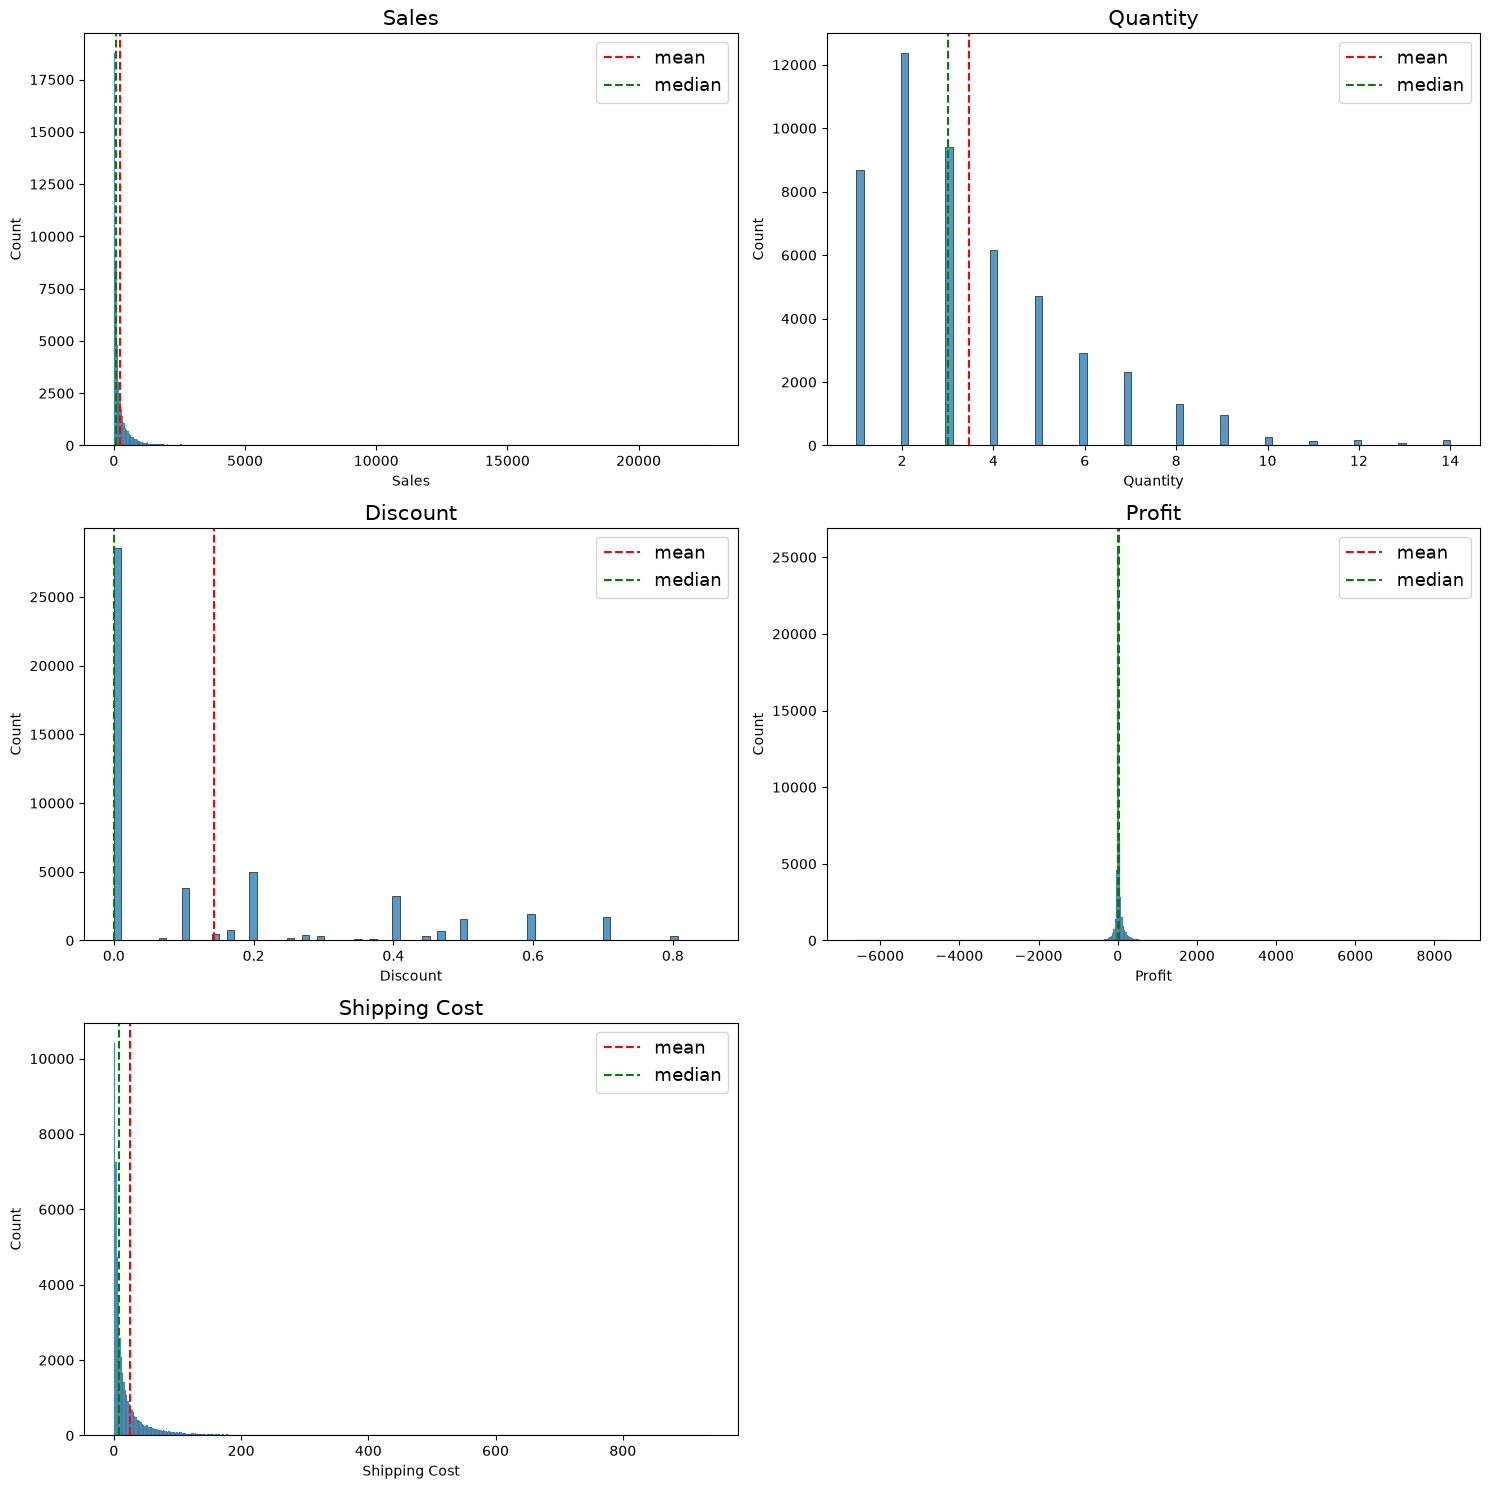

In [46]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for ax, c in zip(axes, numeric_columns):
    sns.histplot(df[c], ax=ax)
    ax.axvline(df[c].mean(), color="red", linestyle="--", label="mean")
    ax.axvline(df[c].median(), color="green", linestyle="--", label="median")
    ax.set_title(c, fontsize=15)
    ax.legend(fontsize=13)
for ax in axes[len(numeric_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

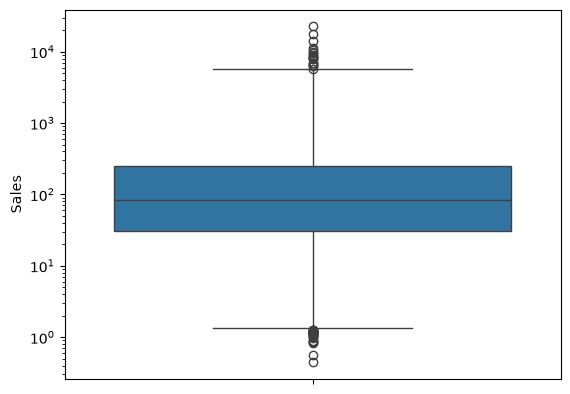

In [47]:
sns.boxplot(df['Sales'] , log_scale=True)
plt.show()

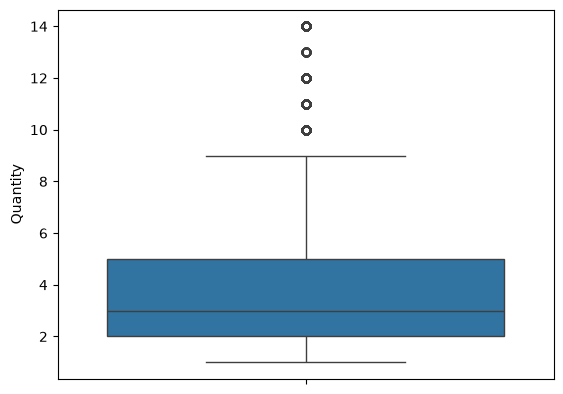

In [48]:
sns.boxplot(df['Quantity'])
plt.show()

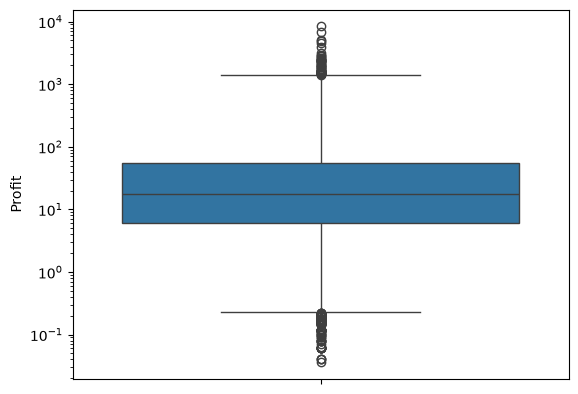

In [49]:
sns.boxplot(df['Profit'] , log_scale=True)
plt.show()

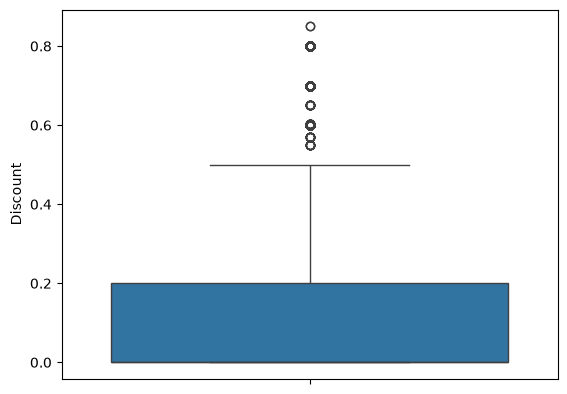

In [50]:
sns.boxplot(df['Discount'])
plt.show()

## Outliers

In [51]:
def outlier_detector(col, method="iqr", k=1.5, z_thresh=3, clip=False) -> pd.Series:
    col = col.replace([np.inf, -np.inf], np.nan)

    if method == "iqr":
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (col < lower) | (col > upper)

        if clip:
            return col.clip(lower, upper)
        return mask

    elif method == "zscore":
        z = col.sub(col.mean()).div(col.std()).abs()
        mask = z > z_thresh

        if clip:
            mean, std = col.mean(), col.std()
            lower = mean - z_thresh * std
            upper = mean + z_thresh * std
            return col.clip(lower, upper)
        return mask

    elif method == "intersection":
        iqr_mask = outlier_detector(col, "iqr", k=k, clip=False)
        z_mask = outlier_detector(col, "zscore", z_thresh=z_thresh, clip=False)
        mask = iqr_mask & z_mask

        if clip:
            q1, q3 = col.quantile(0.25), col.quantile(0.75)
            iqr_val = q3 - q1
            iqr_lower, iqr_upper = q1 - k * iqr_val, q3 + k * iqr_val
            result = col.copy()
            result[mask] = result[mask].clip(iqr_lower, iqr_upper)
            return result
        return mask

In [52]:
for col in numeric_columns:
    print(col, int(outlier_detector(df[col]).sum()) , round((int(outlier_detector(df[col]).sum()) / df[col].shape[0]) * 100 , 2) , '%')

Sales 5466 11.0 %
Quantity 847 1.71 %
Discount 3981 8.01 %
Profit 9448 19.02 %
Shipping Cost 5744 11.56 %


In [53]:
for col in numeric_columns:
    print(col, int(outlier_detector(df[col] , method='zscore').sum()) ,
        round((int(outlier_detector(df[col] , method='zscore').sum()) / df[col].shape[0]) * 100 , 2) , '%')

Sales 996 2.01 %
Quantity 578 1.16 %
Discount 313 0.63 %
Profit 831 1.67 %
Shipping Cost 1007 2.03 %


In [54]:
"""for col in categorical_columns:
    fig = px.pie(
        df,
        names=col,
        title=f"Distribution of {col}"
    )

    fig.update_traces(
        textinfo="percent+label"
    )

    fig.show()"""

'for col in categorical_columns:\n    fig = px.pie(\n        df,\n        names=col,\n        title=f"Distribution of {col}"\n    )\n\n    fig.update_traces(\n        textinfo="percent+label"\n    )\n\n    fig.show()'

In [55]:
def corr_heatmap(numeric_df, method="spearman"):
    cor = numeric_df.corr(method=method)
    plt.figure(figsize=(20,10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
                annot_kws={"size": 15})
    
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.title(f"Correlation Heatmap: {method.capitalize()}" , fontsize=18)
    plt.tight_layout()
    plt.show()

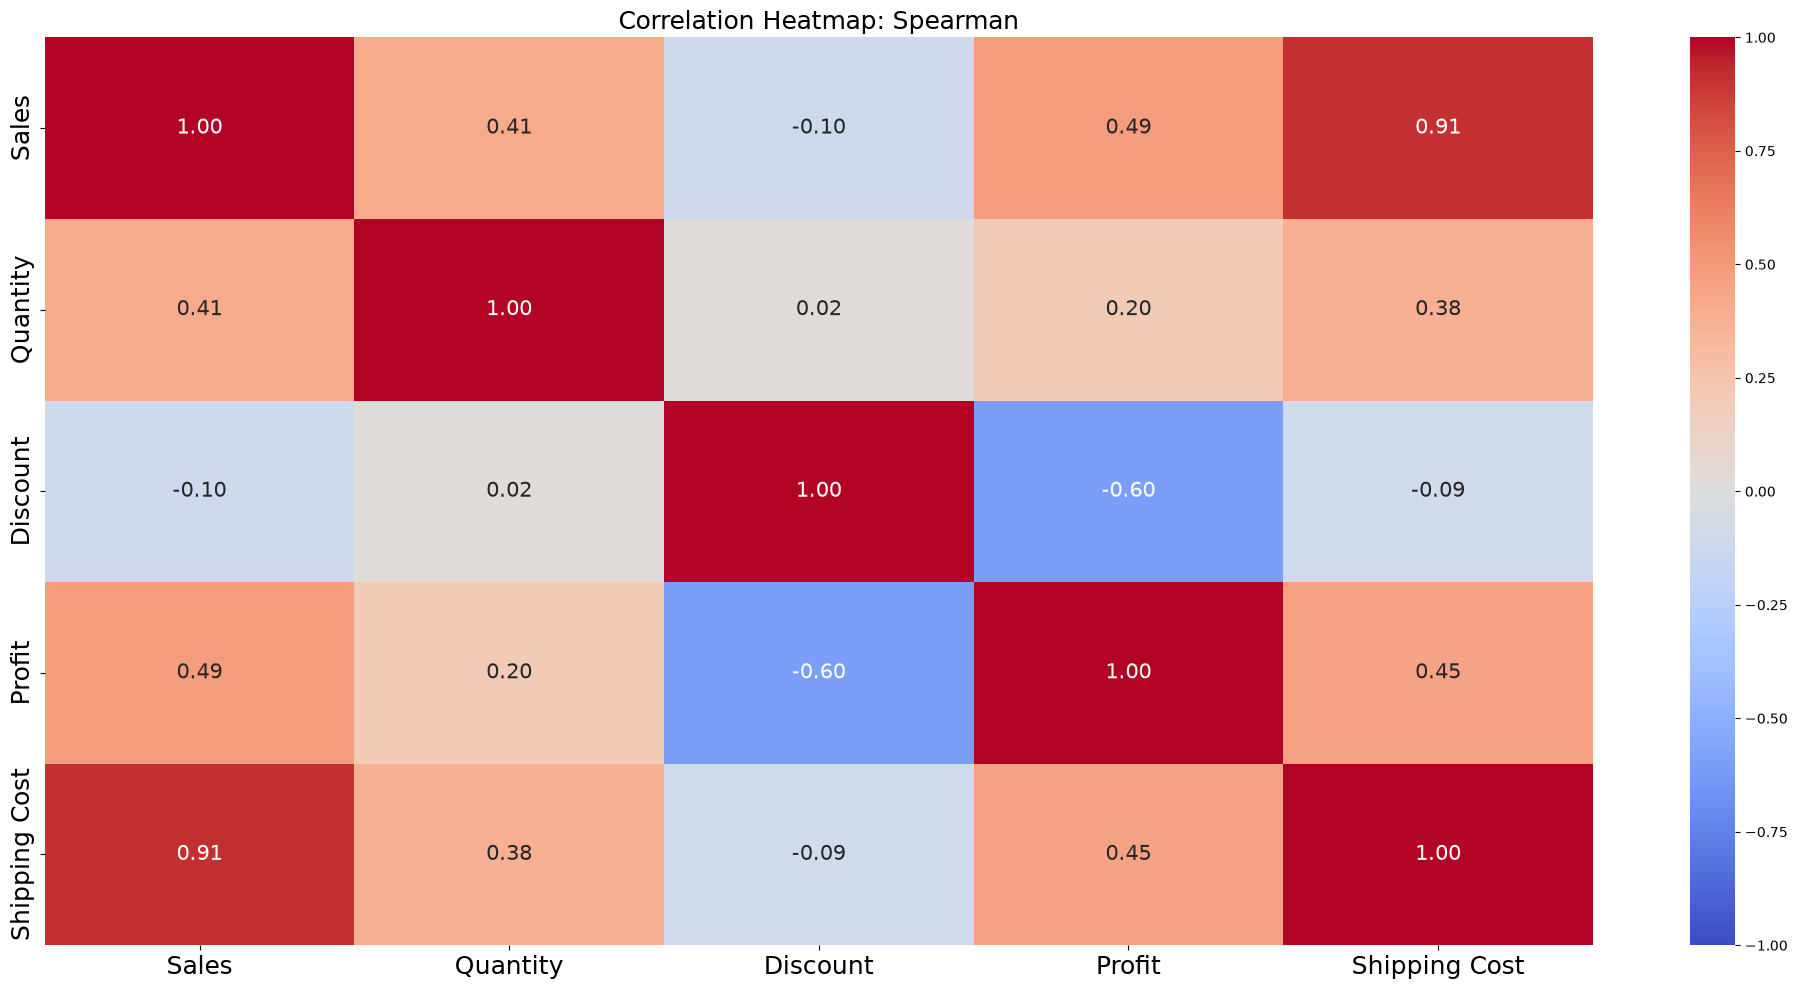

In [56]:
corr_heatmap(df[numeric_columns])

In [57]:
numeric_columns

['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']

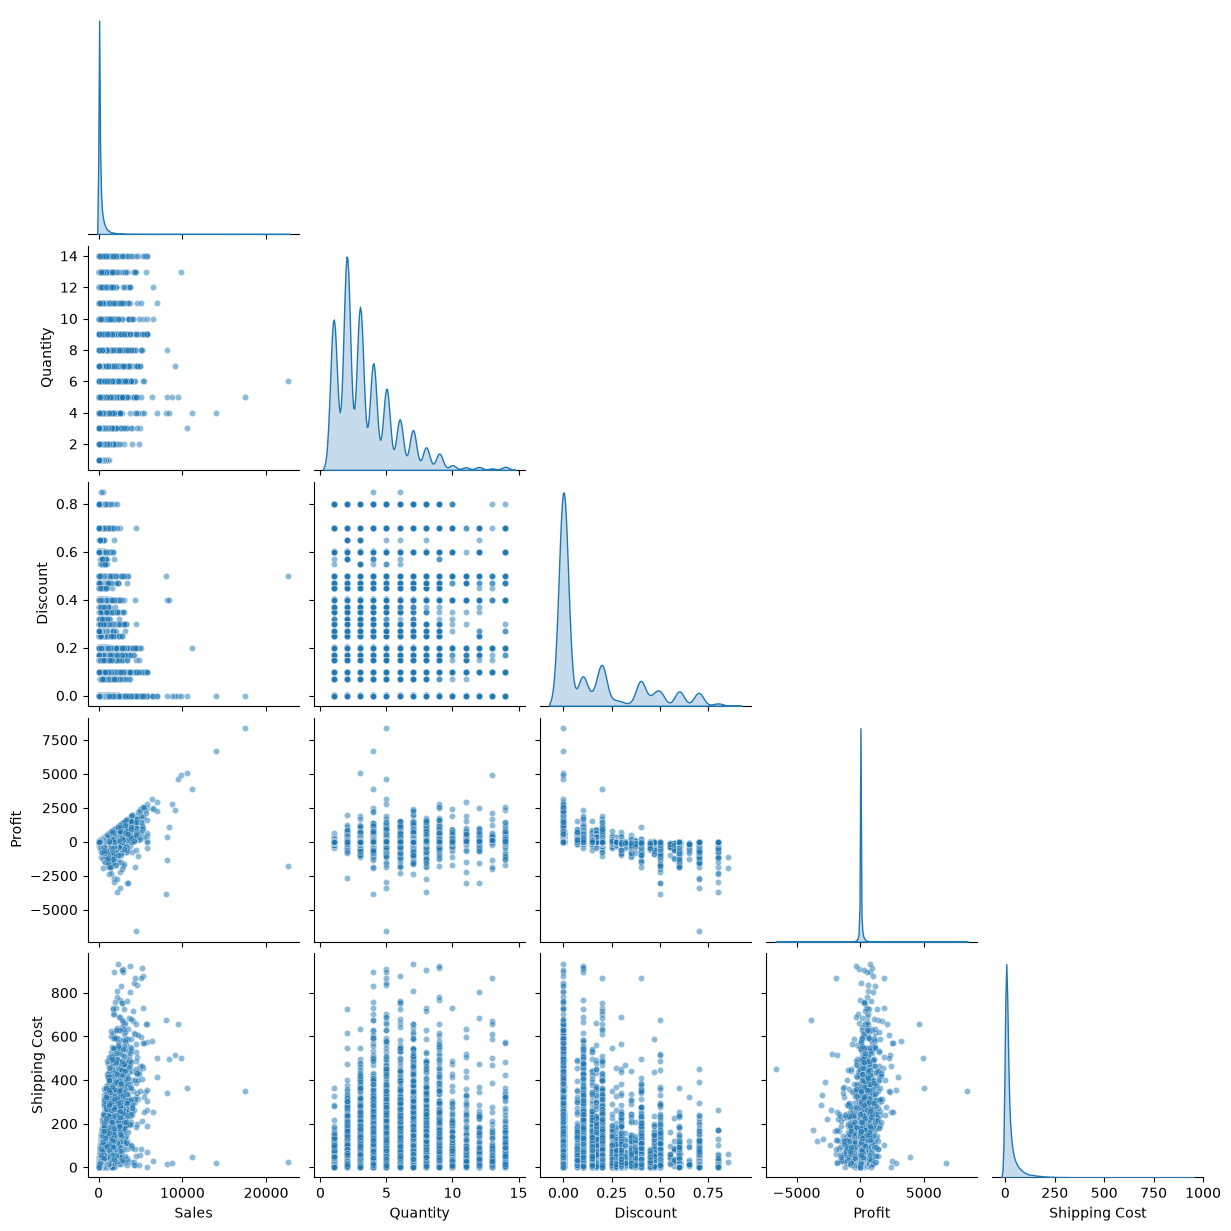

In [58]:
sns.pairplot(df[numeric_columns],diag_kind="kde", corner=True, plot_kws={"alpha": 0.5, "s": 20})

plt.show()

## Statistical Tests

In [99]:
def compare_two_categorical(df, col_1, col_2, alpha=0.05):

    contingency_table = pd.crosstab(df[col_1], df[col_2])
    chi2_stat, p_value, dof, expected_table = chi2_contingency(contingency_table)

    print(f"chi2_stat: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4g}")

    if p_value < alpha:
        print("Reject the Null Hypothesis")
        print(f"There IS a significant association between '{col_1}' and '{col_2}'.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print(f"There is NO significant association between '{col_1}' and '{col_2}'.")

In [60]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):


    categories = data[col_2].dropna().unique()
    X1 = data.loc[data[col_2] == categories[0], col_1].dropna()
    X2 = data.loc[data[col_2] == categories[1], col_1].dropna()

    normal_p0 = stats.normaltest(X1).pvalue
    normal_p1 = stats.normaltest(X2).pvalue
    print(f"Normal test group '{categories[0]}': p = {normal_p0:.4g}")
    print(f"Normal test group '{categories[1]}': p = {normal_p1:.4g}")

    if normal_p0 > alpha and normal_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2)
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
    else:
        try:
            X1_bc, _ = stats.boxcox(X1 - X1.min() + 1)
            X2_bc, _ = stats.boxcox(X2 - X2.min() + 1)
            normal_p0_bc = stats.normaltest(X1_bc).pvalue
            normal_p1_bc = stats.normaltest(X2_bc).pvalue

            if normal_p0_bc > alpha and normal_p1_bc > alpha:
                t, p = stats.ttest_ind(X1_bc, X2_bc)
                print("Normal after Box-Cox -> t-test")
                print(f"t = {t:.4f}, p = {p:.4g}")
            else:
                u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
                print("Not normal after Box-Cox -> Mann-Whitney U")
                print(f"U = {u:.1f}, p = {p:.4g}")
        except Exception:
            u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
            print("Box-Cox not applicable -> Mann-Whitney U")
            print(f"U = {u:.1f}, p = {p:.4g}")

    result = "Significant" if p < alpha else "Not Significant"
    print("Result:", result)
    return p


In [61]:
def anova_test_pro(df, group_col, target_col, equal_var=True):
    temp = df[[group_col, target_col]].dropna()

    if temp[group_col].nunique() < 2:
        print("Insufficient Groups")
        return None, None, "Insufficient Groups"

    if equal_var:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="equal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Classic ANOVA"
    else:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="unequal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Welch ANOVA"

    result = "Significant" if p < 0.05 else "Not Significant"

    print(f"Test used: {test_name}")
    print(f"F-stat = {f_stat:.4f}")
    print(f"p-value = {p:.4g}")
    print(f"Result: {result}")

    return f_stat, p, result


In [62]:
def levene_test(df, group_col, value_col, center='median'):
    groups = []

    for group in df[group_col].dropna().unique():
        sample = df.loc[df[group_col] == group, value_col].dropna()
        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        raise ValueError("Need at least 2 groups with data for Levene test.")

    stat, p = levene(*groups, center=center)
    print(f"P-value is: {p}")

### Returned against Profit

In [63]:
numeric_vs_categorical(df , 'Profit' , 'Returned')

Normal test group '0': p = 0
Normal test group '1': p = 0
Not normal after Box-Cox -> Mann-Whitney U
U = 64445184.0, p = 1.473e-11
Result: Significant


np.float32(1.4732857e-11)

### Profit against Category

In [64]:
levene_test(df , 'Category' , 'Profit')

P-value is: 0.0


In [65]:
anova_test_pro(df , 'Category' , 'Profit' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 163.2780
p-value = 7.414e-71
Result: Significant


(np.float64(163.27795081496774),
 np.float64(7.413535152600924e-71),
 'Significant')

In [84]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Profit',between='Category')
games_howell

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Furniture,Office Supplies,28.232306,16.464212,11.768093,2.172140,5.417740,11321.038590,1.845400e-07,0.085929
1,Furniture,Technology,28.232306,65.458031,-37.225723,3.428619,-10.857351,18223.844820,1.627365e-12,-0.155552
2,Office Supplies,Technology,16.464212,65.458031,-48.993820,2.792366,-17.545628,10806.433967,7.321366e-12,-0.301358


### Profit against Market

In [66]:
levene_test(df , 'Market' , 'Profit')

P-value is: 1.8768267956370035e-28


In [67]:
anova_test_pro(df , 'Market' , 'Profit' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 29.7096
p-value = 3.516e-35
Result: Significant


(np.float64(29.709600743812), np.float64(3.516286412800185e-35), 'Significant')

In [93]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Profit',between='Market')
games_howell[games_howell['pval'] < 0.05].sort_values('diff' , ascending = False)

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
11,Canada,EMEA,46.947926,10.582015,36.365910,6.355446,5.722007,467.837195,3.930222e-07,0.256848
2,APAC,EMEA,39.629162,10.582015,29.047146,2.625125,11.065052,10870.533935,1.020739e-12,0.178524
13,Canada,LATAM,46.947926,21.955399,24.992527,6.125238,4.080254,404.058870,1.057748e-03,0.210830
0,APAC,Africa,39.629162,20.432905,19.196257,2.735233,7.018143,9497.000541,4.783618e-11,0.117020
4,APAC,LATAM,39.629162,21.955399,17.673763,2.004527,8.816925,19693.292046,0.000000e+00,0.119573
18,EU,LATAM,34.331470,21.955399,12.376072,2.172565,5.696527,15338.319840,2.605372e-07,0.084941
5,APAC,US,39.629162,28.831310,10.797852,2.859366,3.776309,18004.588291,3.036134e-03,0.053062
7,Africa,EMEA,20.432905,10.582015,9.850890,3.014469,3.267870,9182.477515,1.873734e-02,0.067935
16,EMEA,LATAM,10.582015,21.955399,-11.373384,2.371423,-4.796015,8070.473782,3.390785e-05,-0.089505
8,Africa,EU,20.432905,34.331470,-13.898565,2.860666,-4.858507,10261.139922,2.475474e-05,-0.084816


### Sales against Segment

In [68]:
levene_test(df , 'Segment' , 'Sales')

P-value is: 0.9273583889007568


In [69]:
anova_test_pro(df , 'Segment' , 'Sales' ,equal_var=True)

Test used: Classic ANOVA
F-stat = 0.0736
p-value = 0.929
Result: Not Significant


(np.float64(0.07360197451253787),
 np.float64(0.9290415037484362),
 'Not Significant')

### Shipping Cost against Ship Mode

In [70]:
df.columns

Index(['Order ID', 'Product ID', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Customer ID', 'Order Priority', 'Order Date',
       'Market', 'Product Name', 'Category', 'Sub-Category', 'Customer Name',
       'Segment', 'Shipping ID', 'Ship Date', 'Ship Mode', 'City', 'State',
       'Country', 'Region', 'Returned'],
      dtype='str')

In [71]:
levene_test(df , 'Ship Mode' , 'Shipping Cost')

P-value is: 0.0


In [72]:
anova_test_pro(df , 'Ship Mode' , 'Shipping Cost' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 256.8061
p-value = 1.043e-159
Result: Significant


(np.float64(256.8060539730035),
 np.float64(1.042665067564094e-159),
 'Significant')

In [95]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Shipping Cost',between='Ship Mode')
games_howell.sort_values('diff' , ascending = False)

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
4,Same Day,Standard Class,42.010181,19.790215,22.219967,1.676922,13.250448,2727.511016,0.000000e+00,0.480965
2,First Class,Standard Class,40.436230,19.790215,20.646015,0.968948,21.307652,8179.588802,1.290967e-12,0.404642
3,Same Day,Second Class,42.010181,30.114565,11.895617,1.781873,6.675906,3456.222458,1.701561e-10,0.171415
5,Second Class,Standard Class,30.114565,19.790215,10.324350,0.690012,14.962561,12762.849796,5.038636e-12,0.214667
1,First Class,Second Class,40.436230,30.114565,10.321665,1.140993,9.046210,13525.236193,0.000000e+00,0.144422
0,First Class,Same Day,40.436230,42.010181,-1.573952,1.907306,-0.825222,4401.267986,8.425425e-01,-0.019367


### Returned against Category

In [100]:
compare_two_categorical(df , 'Returned' , 'Category')

chi2_stat: 9.4753
p-value: 0.008759
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Category'.


### Returned against Discount

In [101]:
df["Has_Discount"] = np.where(df["Discount"] > 0, "Discounted", "No Discount")
df["Has_Discount"] = df["Has_Discount"].astype("category")

In [102]:
compare_two_categorical(df , 'Returned' , 'Has_Discount')

chi2_stat: 9.1686
p-value: 0.002462
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Has_Discount'.


### Returned against Ship Mode

In [103]:
compare_two_categorical(df , 'Returned' , 'Ship Mode')

chi2_stat: 9.0121
p-value: 0.02913
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Ship Mode'.


### Returned against Segment

In [104]:
compare_two_categorical(df , 'Returned' , 'Segment')

chi2_stat: 10.5282
p-value: 0.005174
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Segment'.


### Returned against Segment

In [105]:
compare_two_categorical(df , 'Returned' , 'Market')

chi2_stat: 792.1468
p-value: 7.66e-168
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Market'.


### Market against Category

In [106]:
compare_two_categorical(df , 'Category' , 'Market')

chi2_stat: 558.2167
p-value: 8.755e-112
Reject the Null Hypothesis
There IS a significant association between 'Category' and 'Market'.
